### Final Eval

On Students Data Dataset

1. Find correlations between various features and grade_mean and see which features have a significant impact on it.
2. Find out who got better grades (Boys or Girls). Similarly Find out who got better grades age wise.
3. Count the number of distinct values in each column and drop column with very high distinct values.
4. Replace any missing value of each column by most frequent value having same Grade mean value.
4. Lable encode all other columns.
5. Apply Apriori algorithm to find top 10 most significant rules for Grade mean.
6. Plot Graph of Mean vs top 4 correlated attributes in single plot using subplots.

In [1]:
import pandas as pd
from rich import print as pprint
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../datasets/student_data.csv")

In [3]:
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [4]:
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
grade_cols = ["G1", "G2", "G3"]
df["grade_mean"] = np.sum(df[grade_cols], axis=1) / len(grade_cols)

In [6]:
num_df = df.select_dtypes(include=["int64", "float64"])
corr = num_df.corr()
# print(corr["grade_mean"])
vals = []
for i, row in enumerate(corr["grade_mean"]):
    vals.append((abs(row), i))

vals = sorted(vals, reverse=True)
for v in vals:
    col = corr.columns[v[1]]
    print(f"{col:15} => {corr['grade_mean'][col]:.2f}")

grade_mean      => 1.00
G2              => 0.97
G3              => 0.96
G1              => 0.92
failures        => -0.38
Medu            => 0.22
Fedu            => 0.18
goout           => -0.15
age             => -0.13
studytime       => 0.13
traveltime      => -0.13
Walc            => -0.09
health          => -0.08
Dalc            => -0.07
famrel          => 0.02
absences        => -0.01
freetime        => 0.00


In [7]:
male_ind = df["sex"] == "M"
males = df[male_ind]
mmean = males["grade_mean"].mean()
print(f"mean = {mmean}")
mmeadian = males["grade_mean"].median()
print(f"median = {mmeadian}")
males.head()

mean = 11.073083778966131
median = 11.0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,grade_mean
5,GP,M,16,U,LE3,T,4,3,services,other,...,4,2,1,2,5,10,15,15,15,15.000000
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,1,1,3,0,12,12,11,11.666667
8,GP,M,15,U,LE3,A,3,2,services,other,...,2,2,1,1,1,0,16,18,19,17.666667
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,1,1,1,5,0,14,15,15,14.666667
12,GP,M,15,U,LE3,T,4,4,health,services,...,3,3,1,3,5,2,14,14,14,14.000000


In [8]:
females = df[~male_ind]
fmean = females["grade_mean"].mean()
print(f"mean = {fmean}")
fmeadian = females["grade_mean"].median()
print(f"median = {fmeadian}")
females.head()

mean = 10.325320512820513
median = 10.0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,grade_mean
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,5.666667
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,5.333333
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,8.333333
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,14.666667
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,8.666667


In [9]:
if mmean > fmean:
    print("Males have better mean marks")
else:
    print("Females have better mean marks")

if mmeadian > fmeadian:
    print("Males have better median marks")
else:
    print("Females have better median marks")

Males have better mean marks
Males have better median marks


In [10]:
grade_cols = ["G1", "G2", "G3"]
male_mean = []
male_median = []
female_mean = []
female_median = []
for col in grade_cols:
    male_mean.append(males[col].mean())
    male_median.append(males[col].median())
    female_mean.append(females[col].mean())
    female_median.append(females[col].median())


print("Male Stats")
print("        G1    G2    G3")
print(f"  Mean: {male_mean[0]:.2f} {male_mean[1]:.2f} {male_mean[2]:.2f}")
print(f"Median: {male_median[0]:.2f} {male_median[1]:.2f} {male_median[2]:.2f}")

print("\nFemale Stats")
print("        G1    G2    G3")
print(f"  Mean: {female_mean[0]:.2f} {female_mean[1]:.2f} {female_mean[2]:.2f}")
print(f"Median: {female_median[0]:.2f} {female_median[1]:.2f} {female_median[2]:.2f}")

Male Stats
        G1    G2    G3
  Mean: 11.23 11.07 10.91
Median: 11.00 11.00 11.00

Female Stats
        G1    G2    G3
  Mean: 10.62 10.39 9.97
Median: 10.00 10.00 10.00


In [11]:
ages = sorted(df["age"].unique())
print(ages)
best_avg = 0
best_age_mean = 0
best_meadian = 0
best_age_meadian = 0
for age in ages:
    age_grade_ind = df["age"] == age
    age_grade_df = df[age_grade_ind]
    mean = age_grade_df["grade_mean"].mean()
    meadian = age_grade_df["grade_mean"].median()
    print(f"Age = {age}, Mean = {mean:.2f}, Median = {meadian:.2f}")
    if mean > best_avg:
        best_avg = mean
        best_age_mean = age
    if meadian > best_meadian:
        best_meadian = meadian
        best_age_meadian = age

print(f"Best mean age = {best_age_mean} with {best_avg}")
print(f"Best median age = {best_age_meadian} with {best_meadian}")

[np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]
Age = 15, Mean = 11.28, Median = 10.67
Age = 16, Mean = 11.05, Median = 11.33
Age = 17, Mean = 10.55, Median = 10.67
Age = 18, Mean = 10.13, Median = 10.00
Age = 19, Mean = 9.24, Median = 8.83
Age = 20, Mean = 13.78, Median = 14.67
Age = 21, Mean = 8.33, Median = 8.33
Age = 22, Mean = 7.33, Median = 7.33
Best mean age = 20 with 13.777777777777779
Best median age = 20 with 14.666666666666666


In [12]:
age_mean = {age: {grade: {} for grade in grade_cols} for age in ages}

age_median = {age: {grade: {} for grade in grade_cols} for age in ages}
for age in ages:
    for col in grade_cols:
        age_grade_ind = df["age"] == age
        df_grade = df[col]
        age_grade_df = df_grade[age_grade_ind]
        age_mean[age][col] = round(age_grade_df.mean().item(), 2)
        age_median[age][col] = round(age_grade_df.median().item(), 2)

In [13]:
print("Mean")
pprint(age_mean)
print("Median")
pprint(age_median)

Mean


{
    np.int64(15): {'G1': 11.23, 'G2': 11.37, 'G3': 11.26},
    np.int64(16): {'G1': 10.94, 'G2': 11.18, 'G3': 11.03},
    np.int64(17): {'G1': 10.9, 'G2': 10.48, 'G3': 10.28},
    np.int64(18): {'G1': 10.72, 'G2': 10.13, 'G3': 9.55},
    np.int64(19): {'G1': 10.25, 'G2': 9.25, 'G3': 8.21},
    np.int64(20): {'G1': 13.67, 'G2': 13.67, 'G3': 14.0},
    np.int64(21): {'G1': 10.0, 'G2': 8.0, 'G3': 7.0},
    np.int64(22): {'G1': 6.0, 'G2': 8.0, 'G3': 8.0}
}

Median


{
    np.int64(15): {'G1': 10.5, 'G2': 11.0, 'G3': 11.0},
    np.int64(16): {'G1': 11.0, 'G2': 11.5, 'G3': 11.0},
    np.int64(17): {'G1': 11.0, 'G2': 11.0, 'G3': 11.0},
    np.int64(18): {'G1': 10.0, 'G2': 10.0, 'G3': 10.0},
    np.int64(19): {'G1': 9.5, 'G2': 9.0, 'G3': 9.0},
    np.int64(20): {'G1': 15.0, 'G2': 14.0, 'G3': 15.0},
    np.int64(21): {'G1': 10.0, 'G2': 8.0, 'G3': 7.0},
    np.int64(22): {'G1': 6.0, 'G2': 8.0, 'G3': 8.0}
}

In [14]:
# Check all col
max_dist = 10
to_drop = []

cat_df = df.copy()
for col in cat_df.columns:
    nc = cat_df[col].nunique()
    print(f"{col}, {nc}")
    if nc > max_dist:
        to_drop.append(col)

print(to_drop)
cat_df.drop(columns=to_drop, inplace=True)
cat_df.head()

school, 2
sex, 2
age, 8
address, 2
famsize, 2
Pstatus, 2
Medu, 5
Fedu, 5
Mjob, 5
Fjob, 5
reason, 4
guardian, 3
traveltime, 4
studytime, 4
failures, 4
schoolsup, 2
famsup, 2
paid, 2
activities, 2
nursery, 2
higher, 2
internet, 2
romantic, 2
famrel, 5
freetime, 5
goout, 5
Dalc, 5
Walc, 5
health, 5
absences, 34
G1, 17
G2, 17
G3, 18
grade_mean, 54
['absences', 'G1', 'G2', 'G3', 'grade_mean']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,yes,no,no,4,3,4,1,1,3
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,yes,yes,no,5,3,3,1,1,3
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,yes,no,4,3,2,2,3,3
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,yes,3,2,2,1,1,5
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,yes,no,no,4,3,2,1,2,5


In [15]:
max_dist = 10
to_drop = []

cat_df = df.select_dtypes("str")
for col in cat_df.columns:
    nc = cat_df[col].nunique()
    print(f"{col}, {nc}")
    if nc > max_dist:
        to_drop.append(col)

print(to_drop)
df.drop(columns=to_drop, inplace=True)
df.head()

school, 2
sex, 2
address, 2
famsize, 2
Pstatus, 2
Mjob, 5
Fjob, 5
reason, 4
guardian, 3
schoolsup, 2
famsup, 2
paid, 2
activities, 2
nursery, 2
higher, 2
internet, 2
romantic, 2
[]


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,grade_mean
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,5.666667
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,5.333333
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,8.333333
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,14.666667
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,8.666667


In [16]:
le_df = df.copy()
for col in cat_df.columns:
    le = LabelEncoder()
    le_df[col] = le.fit_transform(le_df[col])

In [17]:
le_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,grade_mean
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,5.666667
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,5.333333
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,8.333333
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,14.666667
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,8.666667


In [18]:
le_df.dtypes

school          int64
sex             int64
age             int64
address         int64
famsize         int64
Pstatus         int64
Medu            int64
Fedu            int64
Mjob            int64
Fjob            int64
reason          int64
guardian        int64
traveltime      int64
studytime       int64
failures        int64
schoolsup       int64
famsup          int64
paid            int64
activities      int64
nursery         int64
higher          int64
internet        int64
romantic        int64
famrel          int64
freetime        int64
goout           int64
Dalc            int64
Walc            int64
health          int64
absences        int64
G1              int64
G2              int64
G3              int64
grade_mean    float64
dtype: object

In [19]:
one_hot_df = le_df.copy()
one_hot_df["grade_mean"] = pd.cut(le_df["grade_mean"], bins=3, labels=False)
dummy = pd.get_dummies(one_hot_df, columns=["grade_mean"])
dummy.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1,G2,G3,grade_mean_0,grade_mean_1,grade_mean_2
0,0,0,18,1,0,0,4,4,0,4,...,1,1,3,6,5,6,6,True,False,False
1,0,0,17,1,0,1,1,1,0,2,...,1,1,3,4,5,5,6,True,False,False
2,0,0,15,1,1,1,1,1,0,2,...,2,3,3,10,7,8,10,False,True,False
3,0,0,15,1,0,1,4,2,1,3,...,1,1,5,2,15,14,15,False,False,True
4,0,0,16,1,0,1,3,3,2,2,...,1,2,5,4,6,10,10,False,True,False


In [20]:
from pyECLAT import ECLAT

grade_cols = ["grade_mean_0", "grade_mean_1", "grade_mean_2"]
for grade_col in grade_cols:
    print("\n\n\nFor", grade_col)
    trans_cols = [
        "schoolsup",
        "famsup",
        "paid",
        "activities",
        "nursery",
        "higher",
        "internet",
        "romantic",
    ]

    grade_df = dummy[dummy[grade_col] == True]
    trans_df = grade_df[trans_cols]

    trans_data = []
    for row in trans_df.values:
        trans_row = []
        for i, col in enumerate(trans_cols):
            if row[i] == 1:
                trans_row.append(col)

        trans_data.append(trans_row)

    # pprint(trans_data[:5])

    data = pd.DataFrame(trans_data)
    my_eclat = ECLAT(data=data, verbose=False)

    # fit the algorithm
    rule_indices, rule_supports = my_eclat.fit(
        min_support=0.2,
        min_combination=2,
        max_combination=len(trans_cols),
        verbose=False,
    )

    rule_supports = dict(
        sorted(rule_supports.items(), key=lambda x: x[1], reverse=True)
    )
    count = 0
    for key in rule_supports:
        print(f"{[w.strip() for w in key.split('&')]}: {rule_supports[key]:.2f}")
        count += 1
        if count >= 10:
            break




For grade_mean_0
['higher', 'nursery']: 0.68
['higher', 'internet']: 0.66
['higher', 'famsup']: 0.64
['famsup', 'nursery']: 0.57
['famsup', 'internet']: 0.57
['nursery', 'internet']: 0.57
['higher', 'famsup', 'nursery']: 0.53
['higher', 'famsup', 'internet']: 0.53
['higher', 'nursery', 'internet']: 0.47
['famsup', 'nursery', 'internet']: 0.46



For grade_mean_1
['higher', 'internet']: 0.79
['higher', 'nursery']: 0.76
['nursery', 'internet']: 0.65
['higher', 'nursery', 'internet']: 0.63
['higher', 'famsup']: 0.58
['famsup', 'internet']: 0.51
['higher', 'activities']: 0.50
['higher', 'famsup', 'internet']: 0.50
['paid', 'higher']: 0.50
['famsup', 'nursery']: 0.47



For grade_mean_2
['higher', 'internet']: 0.91
['higher', 'nursery']: 0.83
['nursery', 'internet']: 0.76
['higher', 'nursery', 'internet']: 0.76
['higher', 'famsup']: 0.59
['famsup', 'internet']: 0.54
['higher', 'famsup', 'internet']: 0.54
['higher', 'activities']: 0.53
['famsup', 'nursery']: 0.51
['higher', 'famsup', 'nur

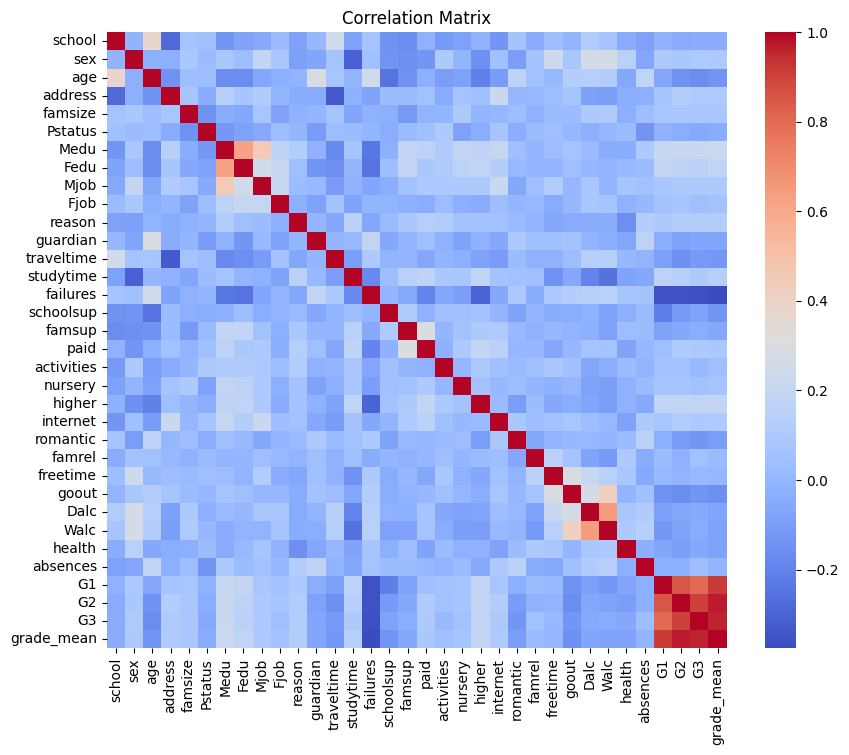

In [21]:
corr = le_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [22]:
vals = []
for i, row in enumerate(corr["grade_mean"]):
    vals.append((abs(row), i))

vals = sorted(vals, reverse=True)

In [23]:
pprint(vals[4:8])

[(0.3757588959269959, 14), (0.22425986840612702, 6), (0.18948349512533394, 20), (0.17585213510215644, 7)]

In [24]:
high_corr_cols = []
for v in vals[1:5]:
    col = corr.columns[v[1]]
    high_corr_cols.append(col)
    print(f"{col:15} => {corr['grade_mean'][col]:.2f}")

print(high_corr_cols)

G2              => 0.97
G3              => 0.96
G1              => 0.92
failures        => -0.38
['G2', 'G3', 'G1', 'failures']


Text(0, 0.5, 'failures')

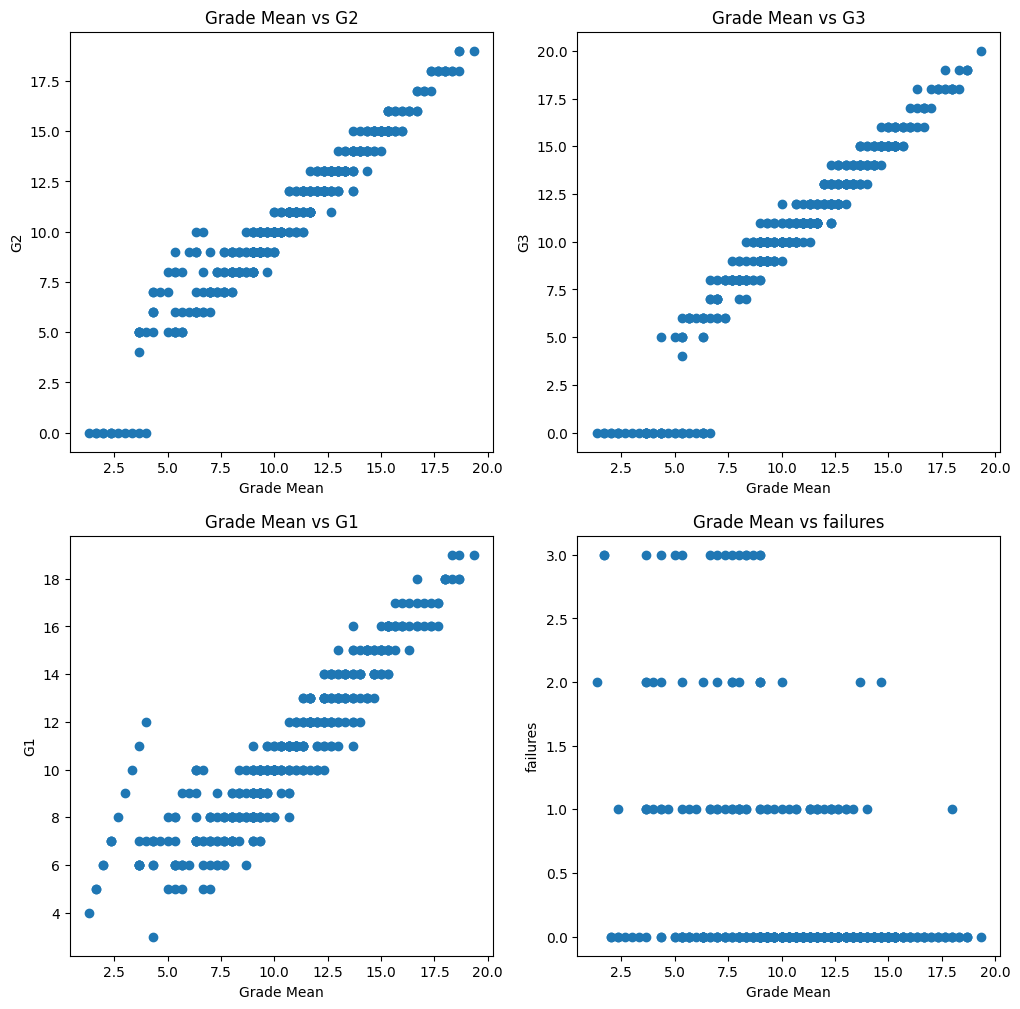

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax[0, 0].scatter(le_df["grade_mean"], le_df[high_corr_cols[0]])
ax[0, 0].set_title(f"Grade Mean vs {high_corr_cols[0]}")
ax[0, 0].set_xlabel("Grade Mean")
ax[0, 0].set_ylabel(high_corr_cols[0])

ax[0, 1].scatter(le_df["grade_mean"], le_df[high_corr_cols[1]])
ax[0, 1].set_title(f"Grade Mean vs {high_corr_cols[1]}")
ax[0, 1].set_xlabel("Grade Mean")
ax[0, 1].set_ylabel(high_corr_cols[1])

ax[1, 0].scatter(le_df["grade_mean"], le_df[high_corr_cols[2]])
ax[1, 0].set_title(f"Grade Mean vs {high_corr_cols[2]}")
ax[1, 0].set_xlabel("Grade Mean")
ax[1, 0].set_ylabel(high_corr_cols[2])

ax[1, 1].scatter(le_df["grade_mean"], le_df[high_corr_cols[3]])
ax[1, 1].set_title(f"Grade Mean vs {high_corr_cols[3]}")
ax[1, 1].set_xlabel("Grade Mean")
ax[1, 1].set_ylabel(high_corr_cols[3])